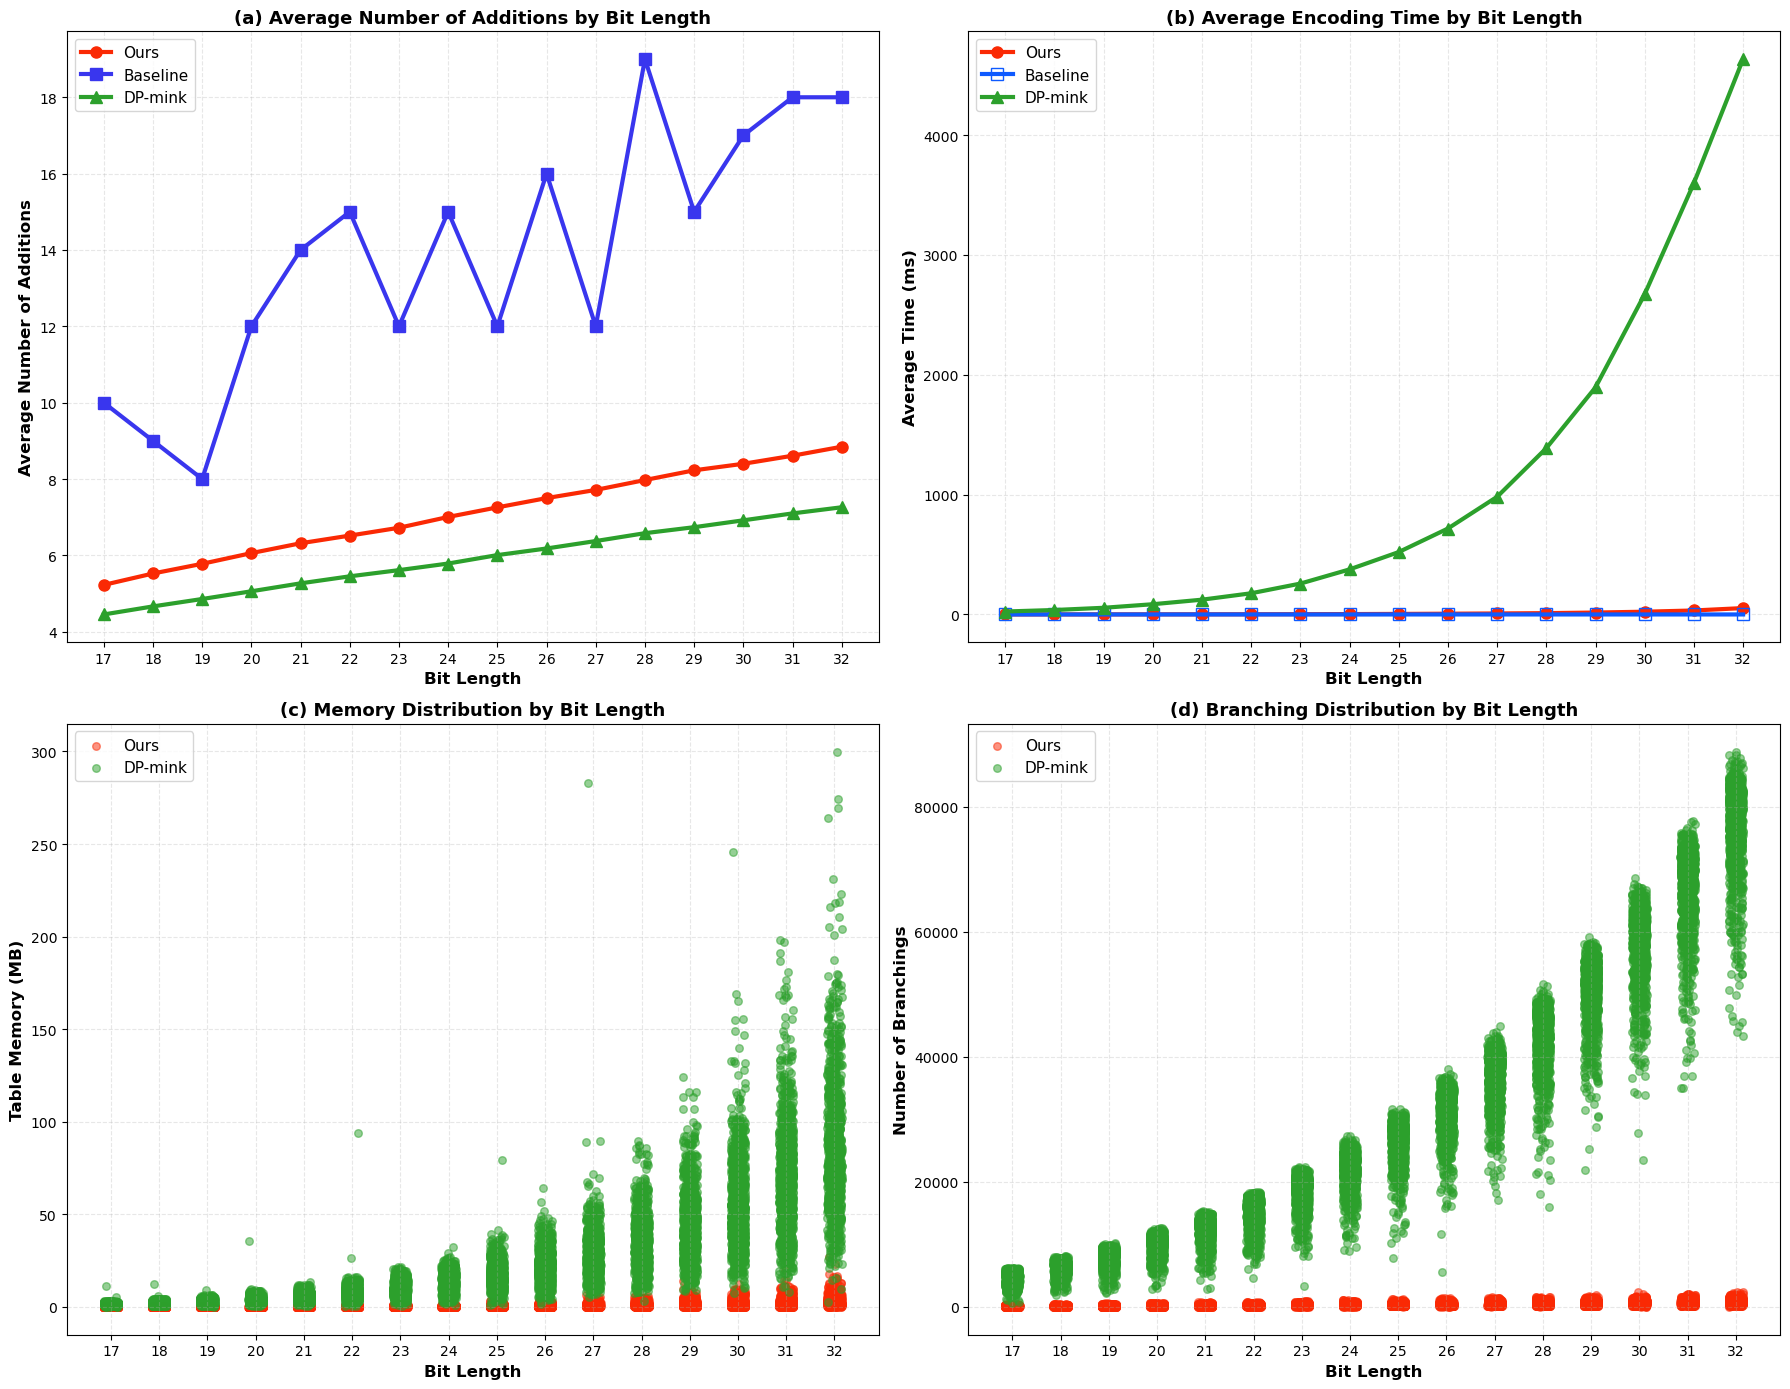

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV文件
df = pd.read_csv('merged_all.csv')

# 添加bit_length列
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)
df['BaseTime_ms'] = df['BaseTime(s)'] * 1000
df['MLTableMB'] = df['MLTableBytes'] / (1024 * 1024)
df['DPTableMB'] = df['DPTableBytes'] / (1024 * 1024)

# 表格数据
table_data = {
    'Length': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
    'Baseline_adds': [10, 9, 8, 12, 14, 15, 12, 15, 12, 16, 12, 19, 15, 17, 18, 18],
    'DP_mink_adds': [4.452, 4.663, 4.857, 5.059, 5.267, 5.451, 5.613, 5.786, 6.007, 6.180, 6.375, 6.581, 6.738, 6.918, 7.099, 7.260],
    'Ours_adds': [5.226, 5.525, 5.779, 6.059, 6.317, 6.518, 6.723, 7.006, 7.257, 7.500, 7.714, 7.973, 8.228, 8.399, 8.610, 8.846]
}
table_df = pd.DataFrame(table_data)

# 按bit_length分组计算平均时间
grouped_time = df.groupby('bit_length').agg({
    'MLTime(ms)': 'mean',
    'BaseTime_ms': 'mean',
    'DPTime(ms)': 'mean'
}).reset_index()

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ===== 子图1 (左上)：Average Number of Additions =====
ax1 = axes[0, 0]
ax1.plot(table_df['Length'], table_df['Ours_adds'], marker='o', linestyle='-', 
        linewidth=3, markersize=8, label='Ours', color='#fa2904')
ax1.plot(table_df['Length'], table_df['Baseline_adds'], marker='s', linestyle='-', 
        linewidth=3, markersize=8, label='Baseline', color='#3936ee')
ax1.plot(table_df['Length'], table_df['DP_mink_adds'], marker='^', linestyle='-', 
        linewidth=3, markersize=8, label='DP-mink', color='#2ca02c')

ax1.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Number of Additions', fontsize=12, fontweight='bold')
ax1.set_title('(a) Average Number of Additions by Bit Length', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(table_df['Length'])

# ===== 子图2 (右上)：Average Encoding Time =====
ax2 = axes[0, 1]
ax2.plot(grouped_time['bit_length'], grouped_time['MLTime(ms)'], 
        marker='o', linestyle='-', linewidth=3, markersize=8, 
        label='Ours', color='#fa2904')
ax2.plot(grouped_time['bit_length'], grouped_time['BaseTime_ms'], 
        marker='s', fillstyle='none', linestyle='-', linewidth=3, markersize=8, 
        label='Baseline', color="#0e5aff")
ax2.plot(grouped_time['bit_length'], grouped_time['DPTime(ms)'], 
        marker='^', linestyle='-', linewidth=3, markersize=8, 
        label='DP-mink', color='#2ca02c')

ax2.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Time (ms)', fontsize=12, fontweight='bold')
ax2.set_title('(b) Average Encoding Time by Bit Length', fontsize=13, fontweight='bold')
ax2.set_xticks(grouped_time['bit_length'])
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3, linestyle='--')

# ===== 子图3 (左下)：Memory Distribution =====
ax3 = axes[1, 0]

# 添加抖动
np.random.seed(42)
jitter = 0.15
df['bit_length_jittered'] = df['bit_length'] + np.random.uniform(-jitter, jitter, len(df))

ax3.scatter(df['bit_length_jittered'], df['MLTableMB'], s=30, alpha=0.5, color="#fa2904", label='Ours')
ax3.scatter(df['bit_length_jittered'], df['DPTableMB'], s=30, alpha=0.5, color='#2ca02c', label='DP-mink')

ax3.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax3.set_ylabel('Table Memory (MB)', fontsize=12, fontweight='bold')
ax3.set_title('(c) Memory Distribution by Bit Length', fontsize=13, fontweight='bold')
ax3.set_xticks(range(17, 33))
ax3.legend(fontsize=11, loc='upper left')
ax3.grid(True, alpha=0.3, linestyle='--')

# ===== 子图4 (右下)：Branching Distribution =====
ax4 = axes[1, 1]

ax4.scatter(df['bit_length_jittered'], df['MLBranchings'], s=30, alpha=0.5, color="#fa2904", label='Ours')
ax4.scatter(df['bit_length_jittered'], df['DPBranchings'], s=30, alpha=0.5, color='#2ca02c', label='DP-mink')

ax4.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Branchings', fontsize=12, fontweight='bold')
ax4.set_title('(d) Branching Distribution by Bit Length', fontsize=13, fontweight='bold')
ax4.set_xticks(range(17, 33))
ax4.legend(fontsize=11, loc='upper left')
ax4.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

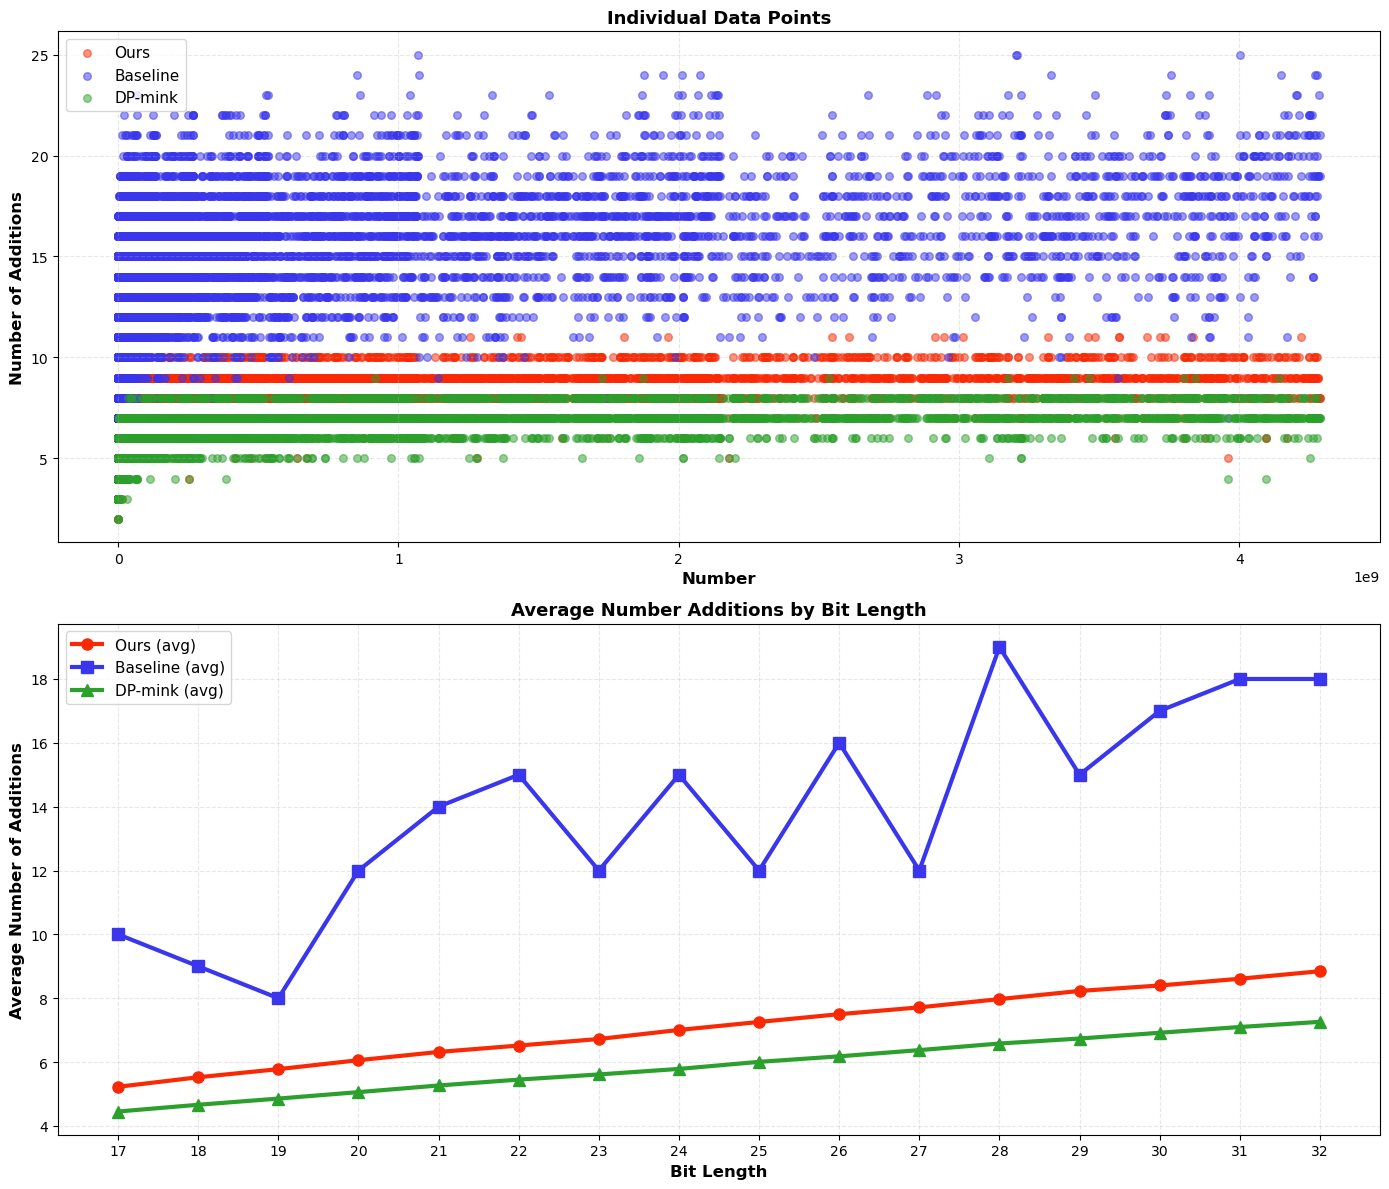

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV文件
df = pd.read_csv('merged_all.csv')

# 添加bit_length列
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)

# 表格数据
table_data = {
    'Length': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
    'Baseline_adds': [10, 9, 8, 12, 14, 15, 12, 15, 12, 16, 12, 19, 15, 17, 18, 18],
    'DP_mink_adds': [4.452, 4.663, 4.857, 5.059, 5.267, 5.451, 5.613, 5.786, 6.007, 6.180, 6.375, 6.581, 6.738, 6.918, 7.099, 7.260],
    'Ours_adds': [5.226, 5.525, 5.779, 6.059, 6.317, 6.518, 6.723, 7.006, 7.257, 7.500, 7.714, 7.973, 8.228, 8.399, 8.610, 8.846]
}
table_df = pd.DataFrame(table_data)

# 创建2x1子图
fig, (ax1, ax2) = plt.subplots(1, 1, figsize=(14, 12))

# # ===== 第一个子图：原始数据点 =====
# ax1.scatter(df['Number'], df['MLSize'], s=30, alpha=0.5, color="#fa2904", label='Ours')
# ax1.scatter(df['Number'], df['BaseSize'], s=30, alpha=0.5, color="#3936ee", label='Baseline')
# ax1.scatter(df['Number'], df['DPSize'], s=30, alpha=0.5, color='#2ca02c', label='DP-mink')

# ax1.set_xlabel('Number', fontsize=12, fontweight='bold')
# ax1.set_ylabel('Number of Additions', fontsize=12, fontweight='bold')
# ax1.set_title('Individual Data Points', fontsize=13, fontweight='bold')
# ax1.legend(fontsize=11, loc='upper left')
# ax1.grid(True, alpha=0.3, linestyle='--')
# ax1.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# ===== 第二个子图：平均值线条（按bit_length） =====
ax2.plot(table_df['Length'], table_df['Ours_adds'], marker='o', linestyle='-', 
        linewidth=3, markersize=8, label='Ours (avg)', color='#fa2904')
ax2.plot(table_df['Length'], table_df['Baseline_adds'], marker='s', linestyle='-', 
        linewidth=3, markersize=8, label='Baseline (avg)', color='#3936ee')
ax2.plot(table_df['Length'], table_df['DP_mink_adds'], marker='^', linestyle='-', 
        linewidth=3, markersize=8, label='DP-mink (avg)', color='#2ca02c')

ax2.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Number of Additions', fontsize=12, fontweight='bold')
ax2.set_title('Average Number Additions by Bit Length', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(table_df['Length'])

plt.tight_layout()
plt.show()

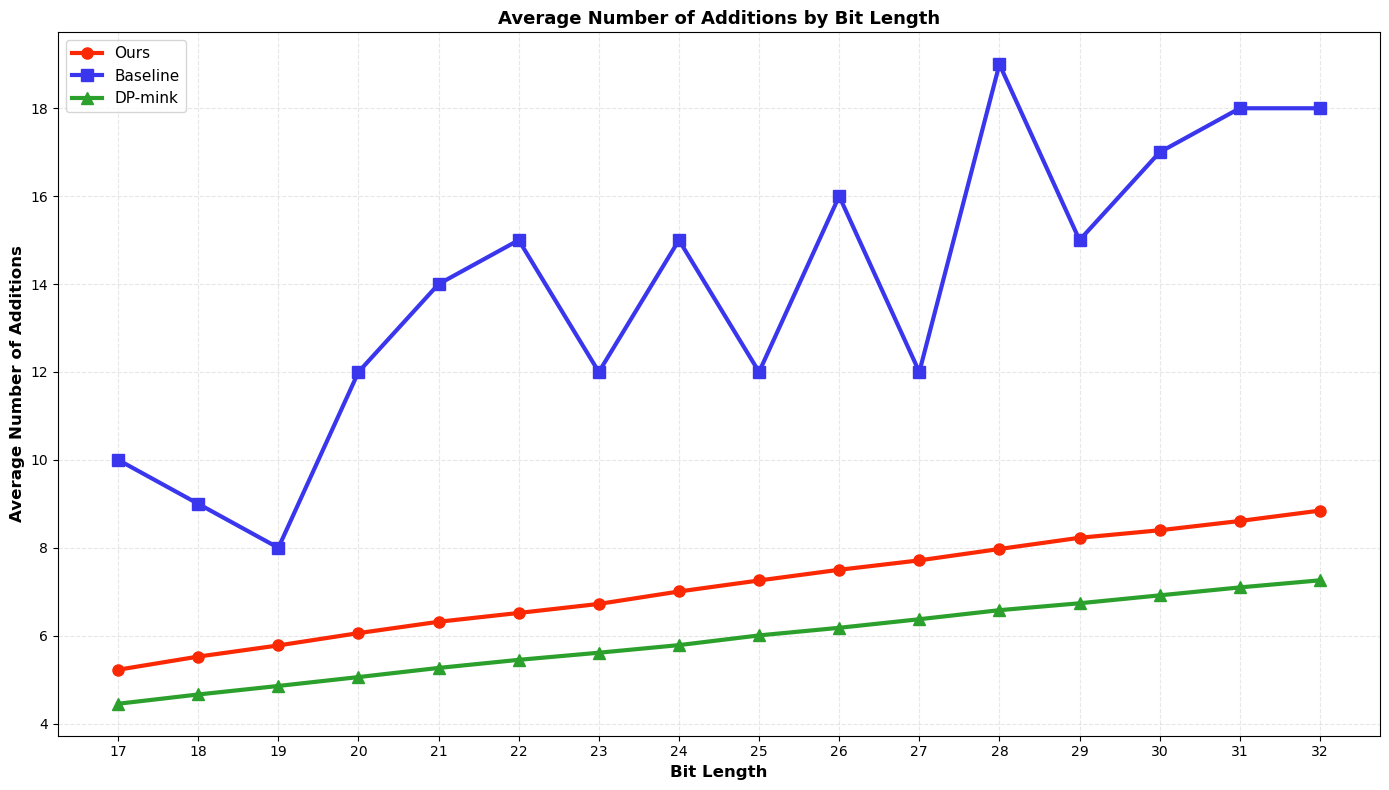

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV文件
df = pd.read_csv('merged_all.csv')

# 添加bit_length列
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)

# 表格数据
table_data = {
    'Length': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
    'Baseline_adds': [10, 9, 8, 12, 14, 15, 12, 15, 12, 16, 12, 19, 15, 17, 18, 18],
    'DP_mink_adds': [4.452, 4.663, 4.857, 5.059, 5.267, 5.451, 5.613, 5.786, 6.007, 6.180, 6.375, 6.581, 6.738, 6.918, 7.099, 7.260],
    'Ours_adds': [5.226, 5.525, 5.779, 6.059, 6.317, 6.518, 6.723, 7.006, 7.257, 7.500, 7.714, 7.973, 8.228, 8.399, 8.610, 8.846]
}
table_df = pd.DataFrame(table_data)

# 创建单个图表
fig, ax = plt.subplots(figsize=(14, 8))

# 绘制平均值线条（按bit_length）
ax.plot(table_df['Length'], table_df['Ours_adds'], marker='o', linestyle='-', 
        linewidth=3, markersize=8, label='Ours', color='#fa2904')
ax.plot(table_df['Length'], table_df['Baseline_adds'], marker='s', linestyle='-', 
        linewidth=3, markersize=8, label='Baseline', color='#3936ee')
ax.plot(table_df['Length'], table_df['DP_mink_adds'], marker='^', linestyle='-', 
        linewidth=3, markersize=8, label='DP-mink', color='#2ca02c')

ax.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Number of Additions', fontsize=12, fontweight='bold')
ax.set_title('Average Number of Additions by Bit Length', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(table_df['Length'])

plt.tight_layout()
plt.show()

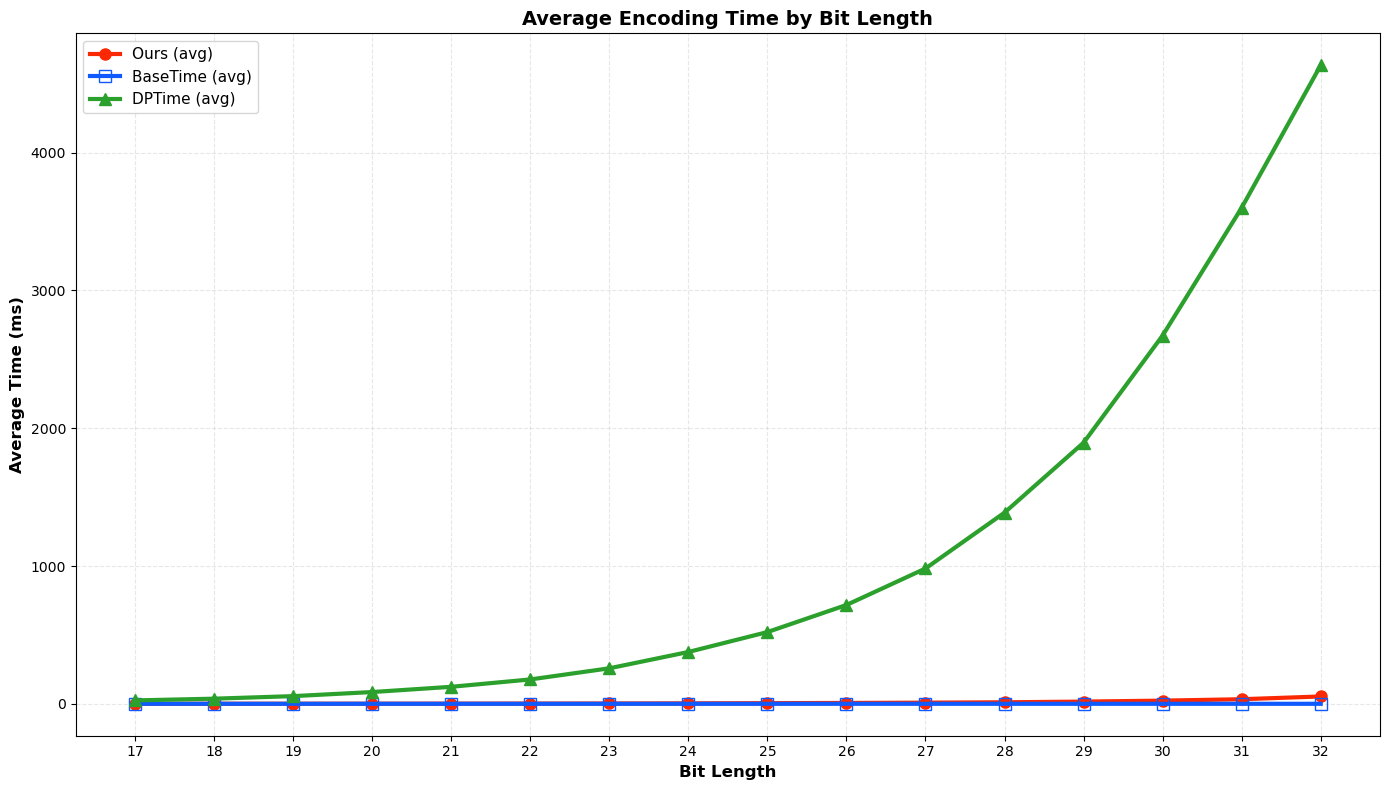

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV文件
df = pd.read_csv('merged_all.csv')
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)
df['BaseTime_ms'] = df['BaseTime(s)'] * 1000

# 按bit_length分组计算平均时间
grouped_time = df.groupby('bit_length').agg({
    'MLTime(ms)': 'mean',
    'BaseTime_ms': 'mean',
    'DPTime(ms)': 'mean'
}).reset_index()


# 创建图表
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(grouped_time['bit_length'], grouped_time['MLTime(ms)'], 
        marker='o', linestyle='-', linewidth=3, markersize=8, 
        label='Ours (avg)', color='#fa2904')
ax.plot(grouped_time['bit_length'], grouped_time['BaseTime_ms'], 
        marker='s', fillstyle='none',linestyle='-', linewidth=3, markersize=8, 
        label='BaseTime (avg)', color="#0e5aff")
ax.plot(grouped_time['bit_length'], grouped_time['DPTime(ms)'], 
        marker='^', linestyle='-', linewidth=3, markersize=8, 
        label='DPTime (avg)', color='#2ca02c')

ax.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontsize=12, fontweight='bold')
ax.set_title('Average Encoding Time by Bit Length', fontsize=14, fontweight='bold')
ax.set_xticks(grouped_time['bit_length'])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

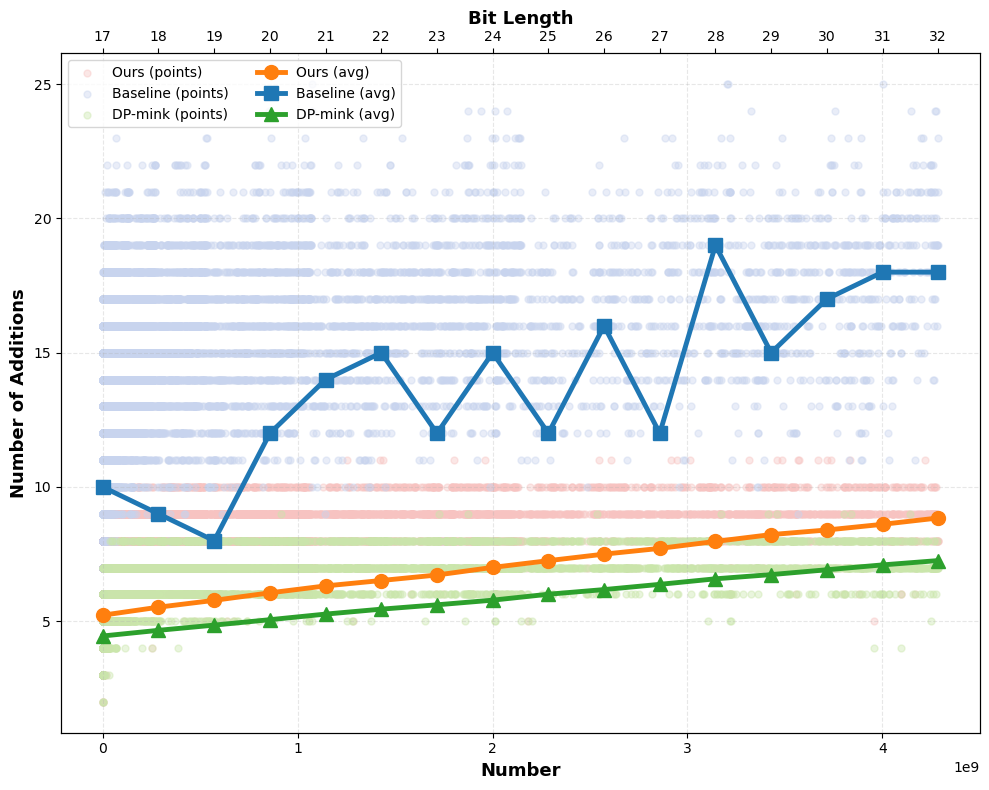

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV文件
df = pd.read_csv('merged_all.csv')
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)

# 表格数据
table_data = {
    'Length': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
    'Baseline_adds': [10, 9, 8, 12, 14, 15, 12, 15, 12, 16, 12, 19, 15, 17, 18, 18],
    'DP_mink_adds': [4.452, 4.663, 4.857, 5.059, 5.267, 5.451, 5.613, 5.786, 6.007, 6.180, 6.375, 6.581, 6.738, 6.918, 7.099, 7.260],
    'Ours_adds': [5.226, 5.525, 5.779, 6.059, 6.317, 6.518, 6.723, 7.006, 7.257, 7.500, 7.714, 7.973, 8.228, 8.399, 8.610, 8.846]
}
table_df = pd.DataFrame(table_data)

# 创建图表
fig, ax1 = plt.subplots(figsize=(10, 8))

# 左轴：原始Number值的散点图
color1 = "#f7c3c1"
color2 = "#c8d4ee"
color3 = "#cae6ab"

ax1.scatter(df['Number'], df['MLSize'], s=25, alpha=0.4, color=color1, label='Ours (points)')
ax1.scatter(df['Number'], df['BaseSize'], s=25, alpha=0.4, color=color2, label='Baseline (points)')
ax1.scatter(df['Number'], df['DPSize'], s=25, alpha=0.4, color=color3, label='DP-mink (points)')

ax1.set_xlabel('Number', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Additions', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y')
ax1.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
ax1.grid(True, alpha=0.3, linestyle='--')

color4 = "#ff7f0e"
color5 = "#1f77b4"
color6 = "#2ca02c"

# 右轴：bit_length的平均值线条
ax2 = ax1.twiny()

ax2.plot(table_df['Length'], table_df['Ours_adds'], marker='o', linestyle='-', 
        linewidth=3.5, markersize=10, label='Ours (avg)', color=color4, zorder=10)
ax2.plot(table_df['Length'], table_df['Baseline_adds'], marker='s', linestyle='-', 
        linewidth=3.5, markersize=10, label='Baseline (avg)', color=color5, zorder=10)
ax2.plot(table_df['Length'], table_df['DP_mink_adds'], marker='^', linestyle='-', 
        linewidth=3.5, markersize=10, label='DP-mink (avg)', color=color6, zorder=10)
ax2.set_xlabel('Bit Length', fontsize=13, fontweight='bold')
ax2.set_xticks(table_df['Length'])

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left', ncol=2)

# plt.title('Comparison of Encoding Quality: Individual Points and Averages', 
#           fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

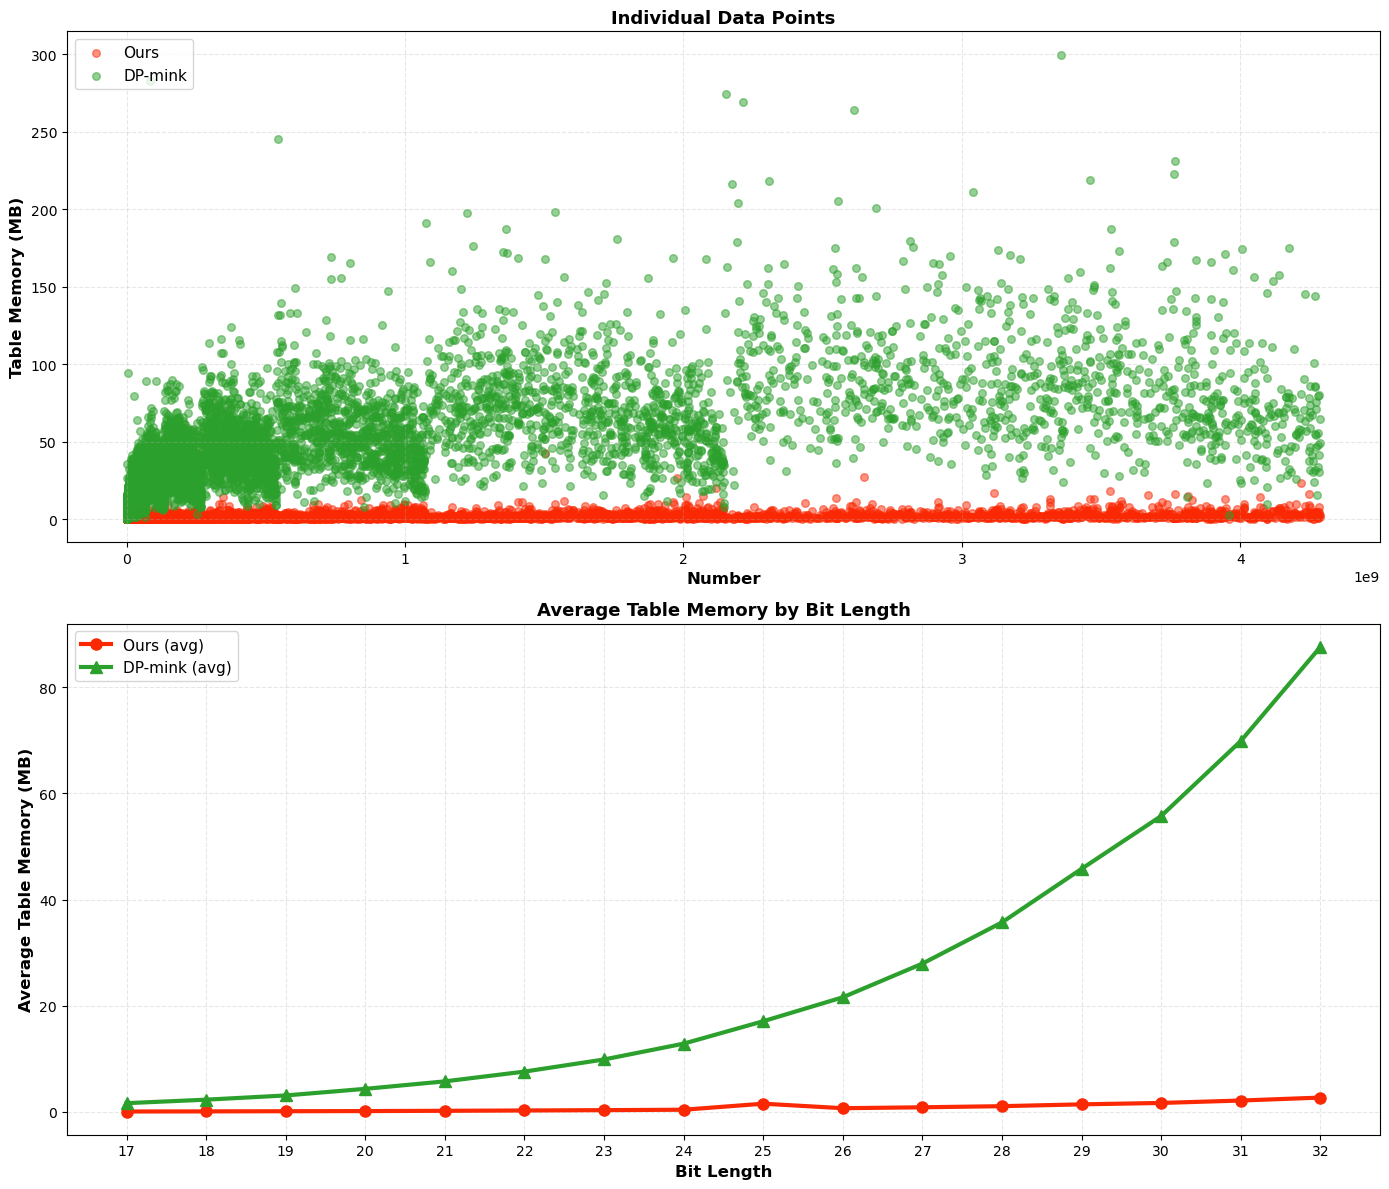

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取CSV文件
df = pd.read_csv('merged_all.csv')

# 添加bit_length列
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)

# 转换为MB
df['MLTableMB'] = df['MLTableBytes'] / (1024 * 1024)
df['DPTableMB'] = df['DPTableBytes'] / (1024 * 1024)

# 表格中的memory数据 (MB)
table_memory_data = {
    'Length': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
    'DP_memory': [1.634, 2.295, 3.089, 4.335, 5.742, 7.583, 9.866, 12.847, 17.070, 21.581, 27.926, 35.688, 45.772, 55.727, 69.843, 87.553],
    'Ours_memory': [0.066, 0.087, 0.118, 0.146, 0.198, 0.258, 0.322, 0.399, 1.536, 0.687, 0.858, 1.070, 1.411, 1.676, 2.131, 2.688]
}
table_memory_df = pd.DataFrame(table_memory_data)

# 创建2x1子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# ===== 第一个子图：原始数据点 =====
ax1.scatter(df['Number'], df['MLTableMB'], s=30, alpha=0.5, color="#fa2904", label='Ours')
ax1.scatter(df['Number'], df['DPTableMB'], s=30, alpha=0.5, color='#2ca02c', label='DP-mink')

ax1.set_xlabel('Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Table Memory (MB)', fontsize=12, fontweight='bold')
ax1.set_title('Individual Data Points', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# ===== 第二个子图：平均值线条（按bit_length） =====
ax2.plot(table_memory_df['Length'], table_memory_df['Ours_memory'], marker='o', linestyle='-', 
        linewidth=3, markersize=8, label='Ours (avg)', color='#fa2904')
ax2.plot(table_memory_df['Length'], table_memory_df['DP_memory'], marker='^', linestyle='-', 
        linewidth=3, markersize=8, label='DP-mink (avg)', color='#2ca02c')

ax2.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Table Memory (MB)', fontsize=12, fontweight='bold')
ax2.set_title('Average Table Memory by Bit Length', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(table_memory_df['Length'])

plt.tight_layout()
plt.show()

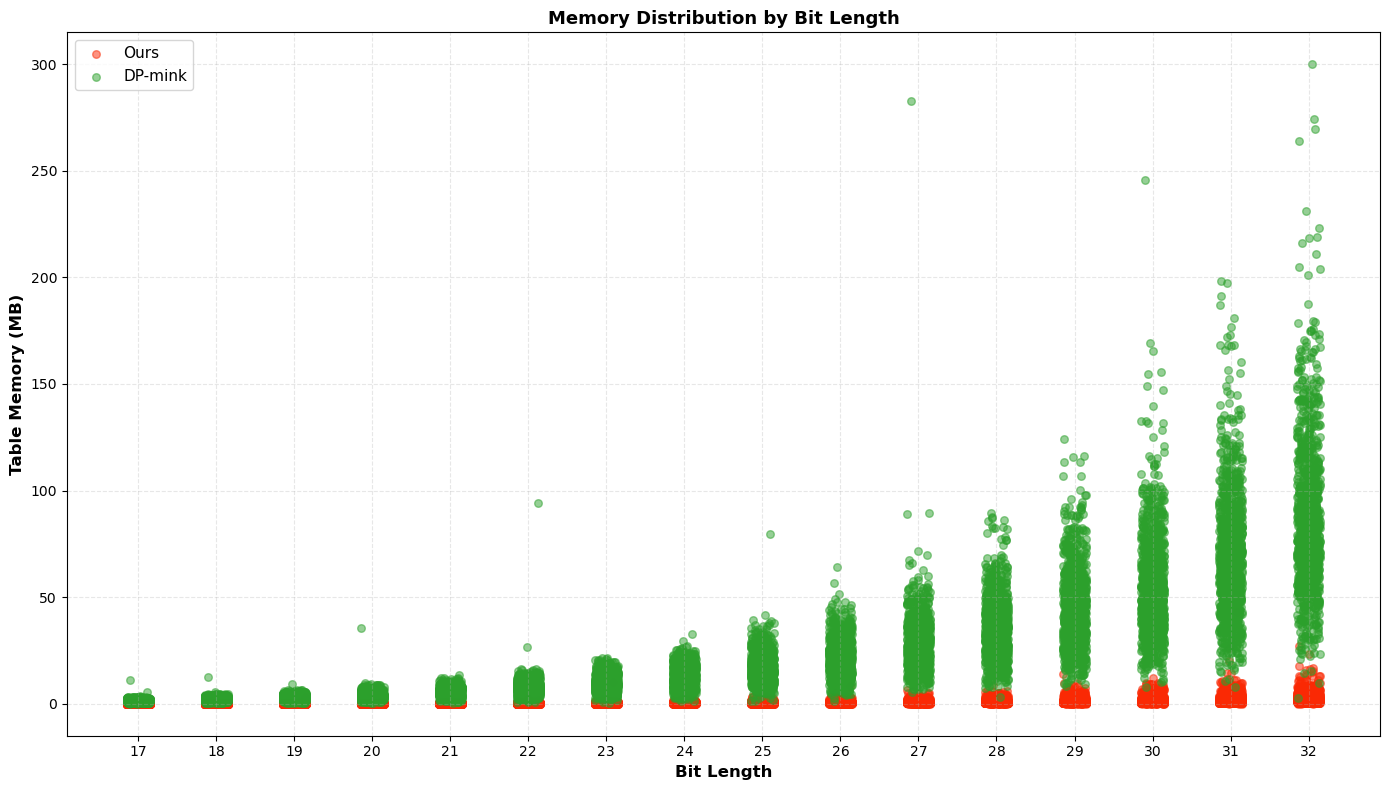

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('merged_all.csv')
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)
df['MLTableMB'] = df['MLTableBytes'] / (1024 * 1024)
df['DPTableMB'] = df['DPTableBytes'] / (1024 * 1024)

# 使用bit_length作为x轴
fig, ax = plt.subplots(figsize=(14, 8))

# 添加一点抖动(jitter)让点不重叠
np.random.seed(42)
jitter = 0.15
df['bit_length_jittered'] = df['bit_length'] + np.random.uniform(-jitter, jitter, len(df))

ax.scatter(df['bit_length_jittered'], df['MLTableMB'], s=30, alpha=0.5, color="#fa2904", label='Ours')
ax.scatter(df['bit_length_jittered'], df['DPTableMB'], s=30, alpha=0.5, color='#2ca02c', label='DP-mink')

ax.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Table Memory (MB)', fontsize=12, fontweight='bold')
ax.set_title('Memory Distribution by Bit Length', fontsize=13, fontweight='bold')
ax.set_xticks(range(17, 33))
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

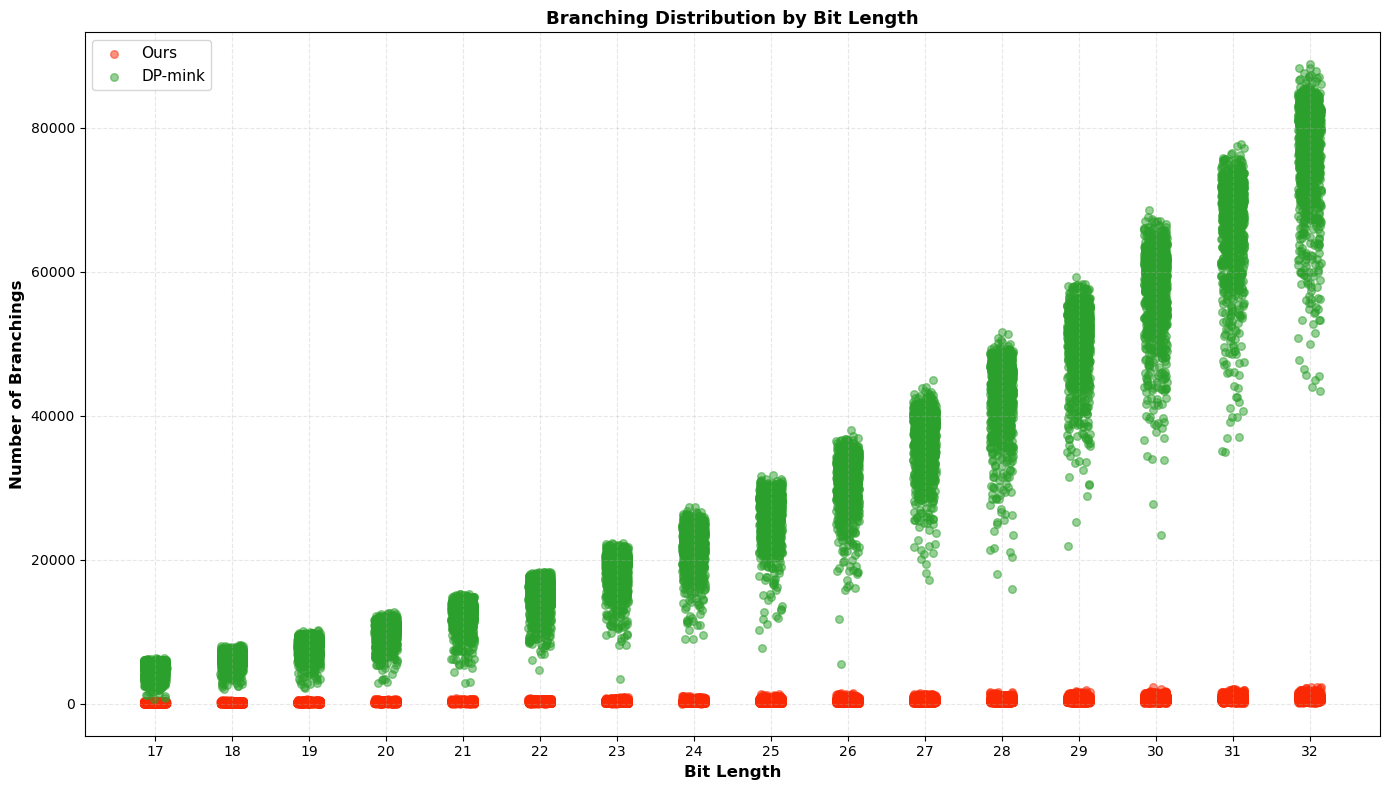

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('merged_all.csv')
df['bit_length'] = df['Number'].apply(lambda x: len(bin(x)) - 2)
df['MLBranchings'] = df['MLBranchings'] 
df['DPBranchings'] = df['DPBranchings'] 

# 使用bit_length作为x轴
fig, ax = plt.subplots(figsize=(14, 8))

# 添加一点抖动(jitter)让点不重叠
np.random.seed(42)
jitter = 0.15
df['bit_length_jittered'] = df['bit_length'] + np.random.uniform(-jitter, jitter, len(df))

ax.scatter(df['bit_length_jittered'], df['MLBranchings'], s=30, alpha=0.5, color="#fa2904", label='Ours')
ax.scatter(df['bit_length_jittered'], df['DPBranchings'], s=30, alpha=0.5, color='#2ca02c', label='DP-mink')

ax.set_xlabel('Bit Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Branchings', fontsize=12, fontweight='bold')
ax.set_title('Branching Distribution by Bit Length', fontsize=13, fontweight='bold')
ax.set_xticks(range(17, 33))
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()